In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()
filename = list(uploaded.keys())[0]

# Read image
img_bgr = cv2.imread(filename)

# Convert BGR -> RGB
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Convert RGB -> HSV
hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)

# Split HSV planes
H, S, V = cv2.split(hsv)

Saving WhatsApp Image 2026-09-09 at 20.02.441.jpeg to WhatsApp Image 2026-09-09 at 20.02.441.jpeg


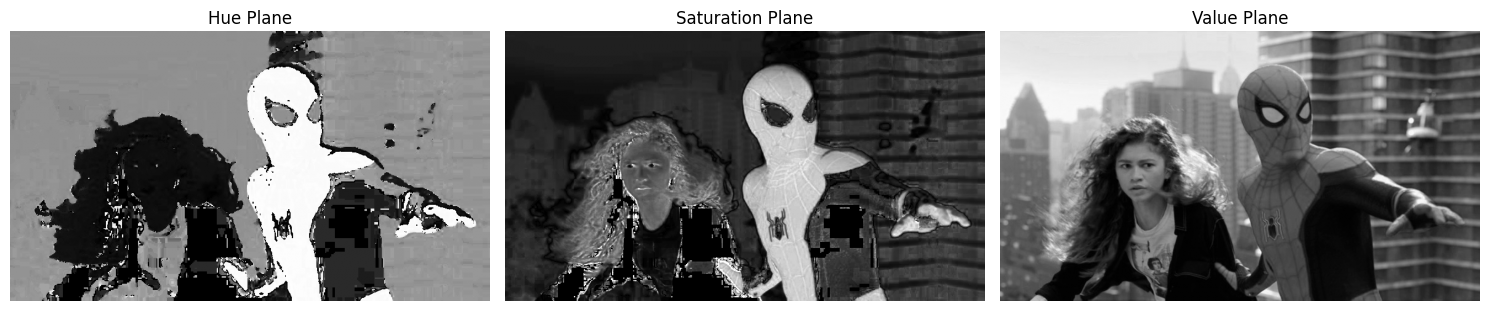

In [3]:
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(H, cmap='gray')
plt.title("Hue Plane")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(S, cmap='gray')
plt.title("Saturation Plane")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(V, cmap='gray')
plt.title("Value Plane")
plt.axis("off")

plt.tight_layout()
plt.show()

In [4]:
def saturation_transform(S, a, sigma=70):

    S_float = S.astype(np.float32)

    S_new = S_float + a * 128 * np.exp(
        -((S_float - 128)**2) / (2 * sigma**2)
    )

    # f(x) = min(..., 255)
    S_new = np.minimum(S_new, 255)

    return S_new.astype(np.uint8)

In [5]:
a = 0.6
sigma = 70

S_enhanced = saturation_transform(S, a, sigma)

In [6]:
hsv_enhanced = cv2.merge([
    H,
    S_enhanced,
    V
])

enhanced_rgb = cv2.cvtColor(
    hsv_enhanced,
    cv2.COLOR_HSV2RGB
)

In [7]:
x = np.arange(256)

y = x + a * 128 * np.exp(
    -((x - 128)**2) / (2 * sigma**2)
)

y = np.minimum(y, 255)

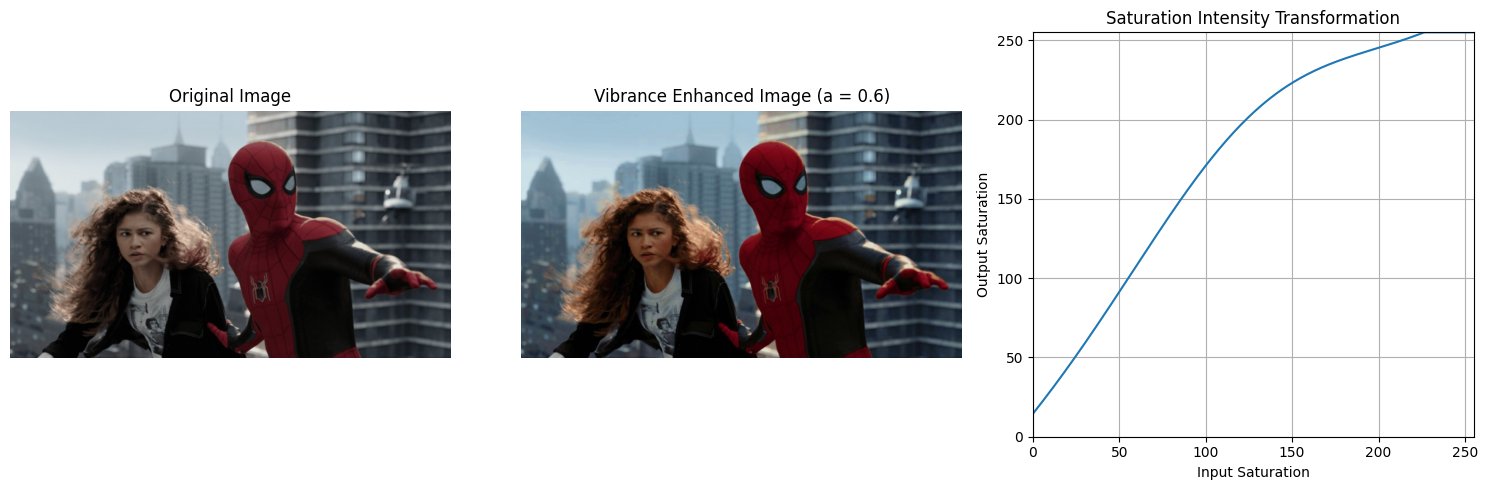

In [8]:
plt.figure(figsize=(15, 5))

# Original
plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")


# Vibrance enhanced
plt.subplot(1, 3, 2)
plt.imshow(enhanced_rgb)
plt.title(f"Vibrance Enhanced Image (a = {a})")
plt.axis("off")


# Transformation
plt.subplot(1, 3, 3)
plt.plot(x, y)
plt.xlabel("Input Saturation")
plt.ylabel("Output Saturation")
plt.title("Saturation Intensity Transformation")
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.grid()

plt.tight_layout()
plt.show()

Testing with several classes

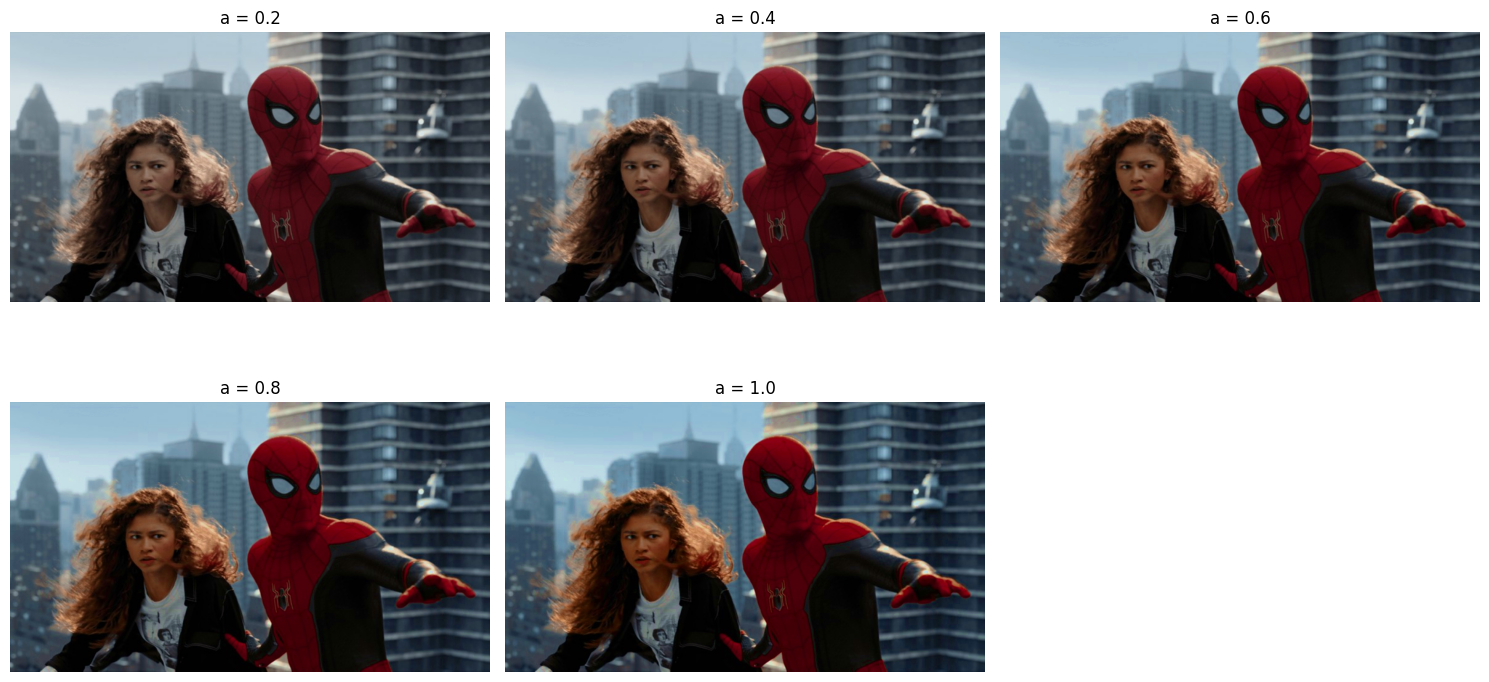

In [9]:
a_values = [0.2, 0.4, 0.6, 0.8, 1.0]

plt.figure(figsize=(15, 8))

for i, a_test in enumerate(a_values):

    S_test = saturation_transform(S, a_test)

    hsv_test = cv2.merge([H, S_test, V])
    rgb_test = cv2.cvtColor(hsv_test, cv2.COLOR_HSV2RGB)

    plt.subplot(2, 3, i + 1)
    plt.imshow(rgb_test)
    plt.title(f"a = {a_test}")
    plt.axis("off")

plt.tight_layout()
plt.show()